Error procesando la línea: Learning Rate: 0.1
Error procesando la línea: Learning Rate: 0.15


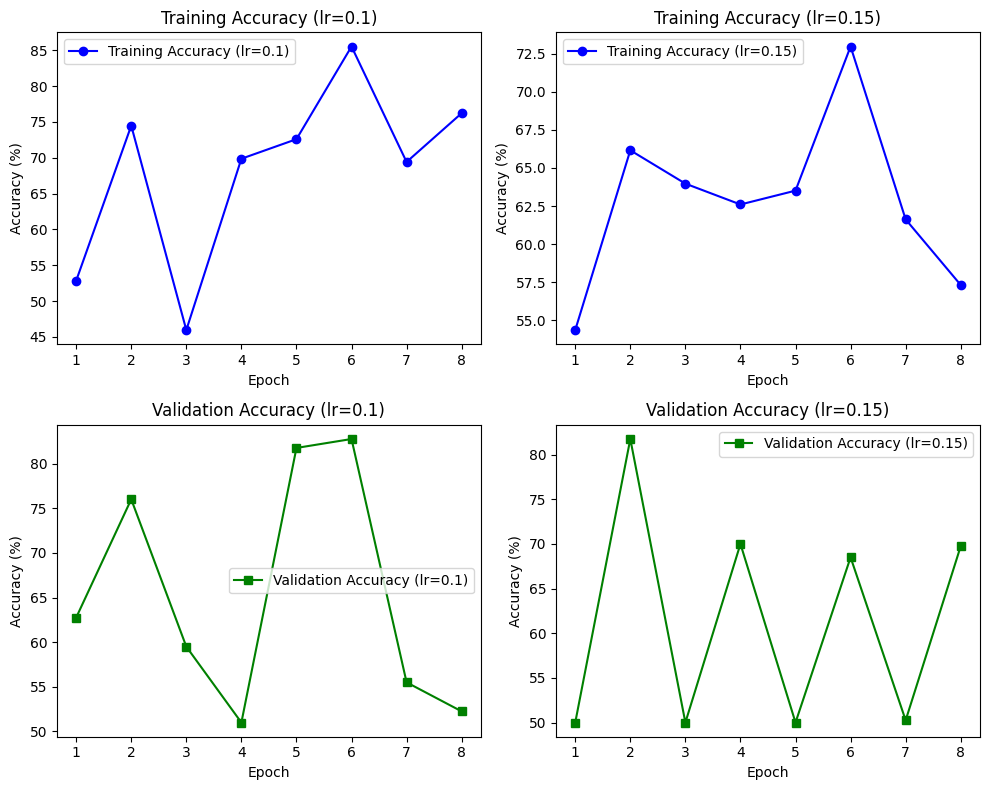

In [1]:
import matplotlib.pyplot as plt

# Nombres de los archivos
files = [
    "results_lr_0.100.txt",
    "results_lr_0.150.txt"
]

# Learning rates correspondientes
learning_rates = [0.1, 0.15]

# Diccionario para almacenar los datos
data = {}

# Leer datos desde los archivos
for file, lr in zip(files, learning_rates):
    data[lr] = {"training": [], "validation": []}
    with open(file, "r") as f:
        lines = f.readlines()
        for line in lines:
            line = line.strip()  # Elimina espacios en blanco iniciales y finales
            if not line:  # Salta líneas vacías
                continue
            # Verificar que la línea tiene exactamente 3 partes
            parts = line.split()
            if len(parts) == 3:
                try:
                    epoch, train_acc, val_acc = map(float, parts)
                    data[lr]["training"].append(train_acc)
                    data[lr]["validation"].append(val_acc)
                except ValueError:
                    print(f"Error procesando la línea: {line}")
                    continue

# Crear la figura
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  # 2 filas, 2 columnas

# Graficar los datos
for i, lr in enumerate(learning_rates):
    # Subgráfico para Training Accuracy
    ax_train = axs[0, i]
    ax_train.plot(
        range(1, len(data[lr]["training"]) + 1),
        data[lr]["training"],
        label=f"Training Accuracy (lr={lr})",
        color="blue",
        marker="o",
    )
    ax_train.set_title(f"Training Accuracy (lr={lr})")
    ax_train.set_xlabel("Epoch")
    ax_train.set_ylabel("Accuracy (%)")
    ax_train.legend()
    ax_train.grid(False)

    # Subgráfico para Validation Accuracy
    ax_val = axs[1, i]
    ax_val.plot(
        range(1, len(data[lr]["validation"]) + 1),
        data[lr]["validation"],
        label=f"Validation Accuracy (lr={lr})",
        color="green",
        marker="s",
    )
    ax_val.set_title(f"Validation Accuracy (lr={lr})")
    ax_val.set_xlabel("Epoch")
    ax_val.set_ylabel("Accuracy (%)")
    ax_val.legend()
    ax_val.grid(False)

# Ajustar la distribución de subgráficos
plt.tight_layout()

# Guardar y mostrar la figura
plt.savefig("comparison_accuracy_results.png")
plt.show()
